# ⚽ Football Analytics Project

## Project Overview

This project analyzes international football match data using Python. It includes data cleaning, exploratory data analysis (EDA), feature engineering, visualization, business insights and final dataset preparation.

## Import Libraries

In [1]:
import pandas as pd

## Load Dataset

In [2]:
df = pd.read_csv("matches_clean.csv.csv")

## Basic Data Exploration

In [3]:
df.head()

,match_id,date,kickoff_time_utc,stage_id,venue_id,home_team_id,away_team_id,home_score,away_score,status,...,away_xg,referee_id,player_of_the_match_id,Total_Goals,Goal_Difference,Match_Result,Match_Year,Match_Month,Home_Team,Away_Team
0,1,11-06-2026,19:00,1,0,1,2,2.0,0.0,Completed,...,0.52,1,16.0,2,0,Home Win,2026,June,Mexico,South Africa
1,2,11-06-2026,23:00,1,7,3,4,2.0,1.0,Completed,...,1.12,2,58.0,3,0,Home Win,2026,June,South Korea,Czechia
2,3,12-06-2026,19:00,1,6,5,6,1.0,1.0,Completed,...,0.98,3,112.0,2,0,Draw,2026,June,Canada,Bosnia and Herzegovina
3,4,12-06-2026,23:00,1,3,13,14,4.0,1.0,Completed,...,0.88,4,332.0,5,0,Home Win,2026,June,USA,Paraguay
4,5,13-06-2026,15:00,1,10,7,8,1.0,1.0,Completed,...,1.54,5,157.0,2,0,Draw,2026,June,Qatar,Switzerland


In [4]:
df.shape

(89, 21)

In [5]:
df.columns

Index(['match_id', 'date', 'kickoff_time_utc', 'stage_id', 'venue_id',
       'home_team_id', 'away_team_id', 'home_score', 'away_score', 'status',
       'home_xg', 'away_xg', 'referee_id', 'player_of_the_match_id',
       'Total_Goals', 'Goal_Difference', 'Match_Result', 'Match_Year',
       'Match_Month', 'Home_Team', 'Away_Team'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89 entries, 0 to 88
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   match_id                89 non-null     int64  
 1   date                    89 non-null     object 
 2   kickoff_time_utc        89 non-null     object 
 3   stage_id                89 non-null     int64  
 4   venue_id                89 non-null     int64  
 5   home_team_id            89 non-null     int64  
 6   away_team_id            89 non-null     int64  
 7   home_score              85 non-null     float64
 8   away_score              85 non-null     float64
 9   status                  89 non-null     object 
 10  home_xg                 85 non-null     float64
 11  away_xg                 85 non-null     float64
 12  referee_id              89 non-null     int64  
 13  player_of_the_match_id  84 non-null     float64
 14  Total_Goals             89 non-null     int6

In [7]:
df.describe()

,match_id,stage_id,venue_id,home_team_id,away_team_id,home_score,away_score,home_xg,away_xg,referee_id,player_of_the_match_id,Total_Goals,Goal_Difference,Match_Year
count,89.000000,89.000000,89.000000,89.000000,89.000000,85.000000,85.000000,85.000000,85.000000,89.000000,84.000000,89.000000,89.0,89.0
mean,45.000000,1.202247,8.460674,23.910112,24.898876,1.800000,1.129412,1.566941,1.085529,8.146067,590.333333,2.797753,0.0,2026.0
std,25.836021,0.431166,4.807797,14.063687,13.851522,1.556859,1.142139,0.928873,0.714634,4.596319,359.684177,1.835135,0.0,0.0
min,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.130000,0.080000,1.000000,7.000000,0.000000,0.0,2026.0
25%,23.000000,1.000000,4.000000,12.000000,14.000000,1.000000,0.000000,0.850000,0.580000,4.000000,247.250000,2.000000,0.0,2026.0
50%,45.000000,1.000000,9.000000,24.000000,25.000000,1.000000,1.000000,1.450000,0.950000,8.000000,572.500000,3.000000,0.0,2026.0
75%,67.000000,1.000000,13.000000,36.000000,37.000000,3.000000,2.000000,1.980000,1.400000,12.000000,919.000000,4.000000,0.0,2026.0
max,89.000000,3.000000,16.000000,48.000000,48.000000,7.000000,5.000000,4.820000,3.580000,16.000000,1207.000000,8.000000,0.0,2026.0


## Data Cleaning

In [8]:
df.isnull().sum()

match_id                  0
date                      0
kickoff_time_utc          0
stage_id                  0
venue_id                  0
home_team_id              0
away_team_id              0
home_score                4
away_score                4
status                    0
home_xg                   4
away_xg                   4
referee_id                0
player_of_the_match_id    5
Total_Goals               0
Goal_Difference           0
Match_Result              0
Match_Year                0
Match_Month               0
Home_Team                 0
Away_Team                 0
dtype: int64

In [9]:
df[df.isnull().any(axis=1)]

,match_id,date,kickoff_time_utc,stage_id,venue_id,home_team_id,away_team_id,home_score,away_score,status,...,away_xg,referee_id,player_of_the_match_id,Total_Goals,Goal_Difference,Match_Result,Match_Year,Match_Month,Home_Team,Away_Team
79,80,01-07-2026,22:00,2,9,45,42,2.0,1.0,Completed,...,0.76,16,NaN,3,0,Home Win,2026,July,England,Congo DR
85,86,04-07-2026,0:00,2,4,15,26,NaN,NaN,Scheduled,...,NaN,6,NaN,0,0,Draw,2026,July,Australia,Egypt
86,87,04-07-2026,4:00,2,13,37,30,NaN,NaN,Scheduled,...,NaN,7,NaN,0,0,Draw,2026,July,Argentina,Cabo Verde
87,88,04-07-2026,7:30,2,12,44,47,NaN,NaN,Scheduled,...,NaN,8,NaN,0,0,Draw,2026,July,Colombia,Ghana
88,89,04-07-2026,23:00,3,11,5,14,NaN,NaN,Scheduled,...,NaN,9,NaN,0,0,Draw,2026,July,Canada,Paraguay


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 89
Columns : 21


In [12]:
df.sample(5)

,match_id,date,kickoff_time_utc,stage_id,venue_id,home_team_id,away_team_id,home_score,away_score,status,...,away_xg,referee_id,player_of_the_match_id,Total_Goals,Goal_Difference,Match_Result,Match_Year,Match_Month,Home_Team,Away_Team
75,76,30-06-2026,7:00,2,8,21,10,1.0,1.0,Completed,...,1.40,12,248.0,2,0,Draw,2026,June,Netherlands,Morocco
7,8,13-06-2026,23:59,1,16,15,16,2.0,0.0,Completed,...,0.72,8,381.0,2,0,Home Win,2026,June,Australia,TÃ¼rkiye
62,63,27-06-2026,22:00,1,13,32,29,0.0,1.0,Completed,...,1.35,15,743.0,1,0,Away Win,2026,June,Uruguay,Spain
88,89,04-07-2026,23:00,3,11,5,14,NaN,NaN,Scheduled,...,NaN,9,NaN,0,0,Draw,2026,July,Canada,Paraguay
72,73,29-06-2026,12:00,2,3,2,5,0.0,1.0,Completed,...,1.32,9,111.0,1,0,Away Win,2026,June,South Africa,Canada


In [13]:
df.tail()

,match_id,date,kickoff_time_utc,stage_id,venue_id,home_team_id,away_team_id,home_score,away_score,status,...,away_xg,referee_id,player_of_the_match_id,Total_Goals,Goal_Difference,Match_Result,Match_Year,Match_Month,Home_Team,Away_Team
84,85,03-07-2026,9:00,2,5,8,38,2.0,0.0,Completed,...,0.73,5,189.0,2,0,Home Win,2026,July,Switzerland,Algeria
85,86,04-07-2026,0:00,2,4,15,26,NaN,NaN,Scheduled,...,NaN,6,NaN,0,0,Draw,2026,July,Australia,Egypt
86,87,04-07-2026,4:00,2,13,37,30,NaN,NaN,Scheduled,...,NaN,7,NaN,0,0,Draw,2026,July,Argentina,Cabo Verde
87,88,04-07-2026,7:30,2,12,44,47,NaN,NaN,Scheduled,...,NaN,8,NaN,0,0,Draw,2026,July,Colombia,Ghana
88,89,04-07-2026,23:00,3,11,5,14,NaN,NaN,Scheduled,...,NaN,9,NaN,0,0,Draw,2026,July,Canada,Paraguay


In [14]:
df["Home_Team"]

0          Mexico
1     South Korea
2          Canada
3             USA
4           Qatar
         ...     
84    Switzerland
85      Australia
86      Argentina
87       Colombia
88         Canada
Name: Home_Team, Length: 89, dtype: object

# Match Status Analysis
Analyzing completed matches and match status distribution.

In [15]:
df[["Home_Team", "Away_Team"]]

,Home_Team,Away_Team
0,Mexico,South Africa
1,South Korea,Czechia
2,Canada,Bosnia and Herzegovina
3,USA,Paraguay
4,Qatar,Switzerland
...,...,...
84,Switzerland,Algeria
85,Australia,Egypt
86,Argentina,Cabo Verde
87,Colombia,Ghana


In [16]:
completed_matches = df[df["status"] == "Completed"]
completed_matches

,match_id,date,kickoff_time_utc,stage_id,venue_id,home_team_id,away_team_id,home_score,away_score,status,...,away_xg,referee_id,player_of_the_match_id,Total_Goals,Goal_Difference,Match_Result,Match_Year,Match_Month,Home_Team,Away_Team
0,1,11-06-2026,19:00,1,0,1,2,2.0,0.0,Completed,...,0.52,1,16.0,2,0,Home Win,2026,June,Mexico,South Africa
1,2,11-06-2026,23:00,1,7,3,4,2.0,1.0,Completed,...,1.12,2,58.0,3,0,Home Win,2026,June,South Korea,Czechia
2,3,12-06-2026,19:00,1,6,5,6,1.0,1.0,Completed,...,0.98,3,112.0,2,0,Draw,2026,June,Canada,Bosnia and Herzegovina
3,4,12-06-2026,23:00,1,3,13,14,4.0,1.0,Completed,...,0.88,4,332.0,5,0,Home Win,2026,June,USA,Paraguay
4,5,13-06-2026,15:00,1,10,7,8,1.0,1.0,Completed,...,1.54,5,157.0,2,0,Draw,2026,June,Qatar,Switzerland
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,81,02-07-2026,2:00,2,16,25,34,3.0,2.0,Completed,...,3.58,1,632.0,5,0,Home Win,2026,July,Belgium,Senegal
81,82,02-07-2026,6:00,2,15,13,6,2.0,0.0,Completed,...,0.25,2,329.0,2,0,Home Win,2026,July,USA,Bosnia and Herzegovina
82,83,03-07-2026,1:00,2,3,29,39,3.0,0.0,Completed,...,0.32,3,749.0,3,0,Home Win,2026,July,Spain,Austria
83,84,03-07-2026,5:00,2,6,41,46,2.0,1.0,Completed,...,1.34,4,1047.0,3,0,Home Win,2026,July,Portugal,Croatia


# Team Participation Analysis
Analyzing the frequency of teams appearing in matches.

In [17]:
completed_matches.shape

(85, 21)

In [18]:
df["Home_Team"].value_counts()

Home_Team
Mexico                    3
Netherlands               3
England                   3
Portugal                  3
Argentina                 3
France                    3
Belgium                   3
Switzerland               3
Spain                     3
Germany                   3
Colombia                  3
Brazil                    3
USA                       3
Canada                    3
Jordan                    2
Norway                    2
Panama                    2
Uruguay                   2
New Zealand               2
Tunisia                   2
South Africa              2
Ecuador                   2
TÃ¼rkiye                  2
Scotland                  2
Czechia                   2
CÃ´te d'Ivoire            2
Australia                 2
South Korea               1
Morocco                   1
Congo DR                  1
Algeria                   1
Senegal                   1
Cabo Verde                1
Egypt                     1
Japan                     1
CuraÃ§ao  

# Goal Scoring Analysis
Examining total goals, average goals, highest scoring matches, and match results.

In [19]:
df.tail()

df["Home_Team"]

df[["Home_Team", "Away_Team"]]

completed_matches = df[df["status"] == "Completed"]
completed_matches

completed_matches.shape

df["Home_Team"].value_counts()

Home_Team
Mexico                    3
Netherlands               3
England                   3
Portugal                  3
Argentina                 3
France                    3
Belgium                   3
Switzerland               3
Spain                     3
Germany                   3
Colombia                  3
Brazil                    3
USA                       3
Canada                    3
Jordan                    2
Norway                    2
Panama                    2
Uruguay                   2
New Zealand               2
Tunisia                   2
South Africa              2
Ecuador                   2
TÃ¼rkiye                  2
Scotland                  2
Czechia                   2
CÃ´te d'Ivoire            2
Australia                 2
South Korea               1
Morocco                   1
Congo DR                  1
Algeria                   1
Senegal                   1
Cabo Verde                1
Egypt                     1
Japan                     1
CuraÃ§ao  

In [20]:
df["Total_Goals"].sum()

np.int64(249)

In [21]:
df["Total_Goals"].mean()

np.float64(2.797752808988764)

In [22]:
df[df["Total_Goals"] == df["Total_Goals"].max()]

,match_id,date,kickoff_time_utc,stage_id,venue_id,home_team_id,away_team_id,home_score,away_score,status,...,away_xg,referee_id,player_of_the_match_id,Total_Goals,Goal_Difference,Match_Result,Match_Year,Match_Month,Home_Team,Away_Team
8,9,14-06-2026,15:00,1,9,17,18,7.0,1.0,Completed,...,0.44,9,423.0,8,0,Home Win,2026,June,Germany,CuraÃ§ao


In [23]:
df["Match_Result"].value_counts()

Match_Result
Home Win    43
Draw        26
Away Win    20
Name: count, dtype: int64

In [24]:
df.groupby("Home_Team")["home_score"].mean().sort_values(ascending=False)

Home_Team
Sweden                    5.000000
Senegal                   5.000000
Morocco                   4.000000
Canada                    3.500000
Germany                   3.333333
France                    3.000000
Congo DR                  3.000000
Algeria                   3.000000
Bosnia and Herzegovina    3.000000
Austria                   3.000000
Switzerland               2.666667
Portugal                  2.666667
USA                       2.666667
Netherlands               2.666667
Argentina                 2.500000
Spain                     2.333333
Norway                    2.000000
South Korea               2.000000
England                   2.000000
Croatia                   2.000000
IR Iran                   2.000000
Brazil                    2.000000
Australia                 2.000000
Mexico                    1.666667
TÃ¼rkiye                  1.500000
Belgium                   1.333333
Saudi Arabia              1.000000
Qatar                     1.000000
Uruguay   

# Data Visualization Setup
Importing visualization libraries for graphical analysis.

In [25]:
df.groupby("Home_Team")["home_score"].sum().sort_values(ascending=False).head(10)

Home_Team
Germany        10.0
France          9.0
Portugal        8.0
Netherlands     8.0
Switzerland     8.0
USA             8.0
Canada          7.0
Spain           7.0
England         6.0
Brazil          6.0
Name: home_score, dtype: float64

# Top Goal Scoring Teams
Analyzing teams with the highest number of goals scored.

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis (EDA)

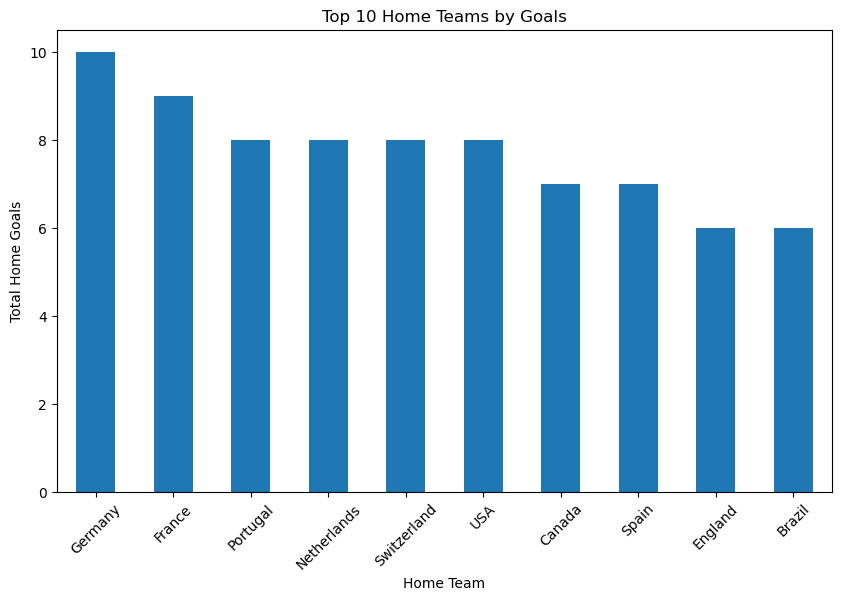

In [27]:
top_home_goals = (
    df.groupby("Home_Team")["home_score"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))
top_home_goals.plot(kind="bar")

plt.title("Top 10 Home Teams by Goals")
plt.xlabel("Home Team")
plt.ylabel("Total Home Goals")

plt.xticks(rotation=45)

plt.show()

In [28]:
match_result = df["Match_Result"].value_counts()
match_result

Match_Result
Home Win    43
Draw        26
Away Win    20
Name: count, dtype: int64

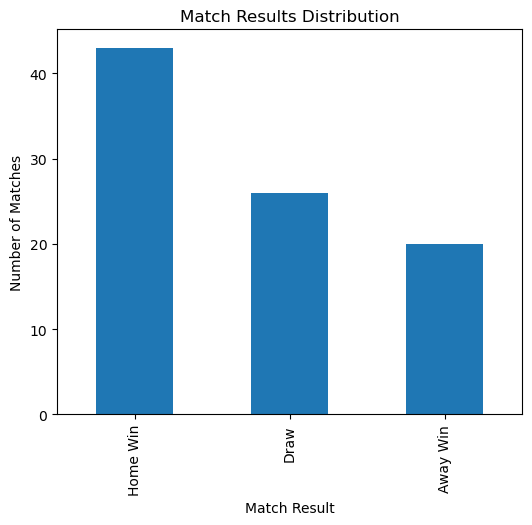

In [29]:
plt.figure(figsize=(6,5))

match_result.plot(kind="bar")

plt.title("Match Results Distribution")
plt.xlabel("Match Result")
plt.ylabel("Number of Matches")

plt.show()

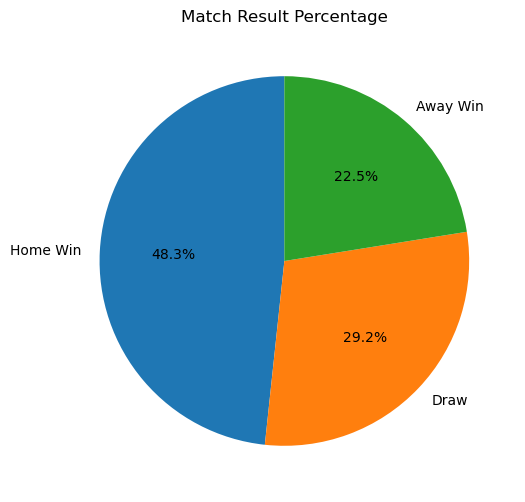

In [30]:
plt.figure(figsize=(6,6))

match_result.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")
plt.title("Match Result Percentage")

plt.show()

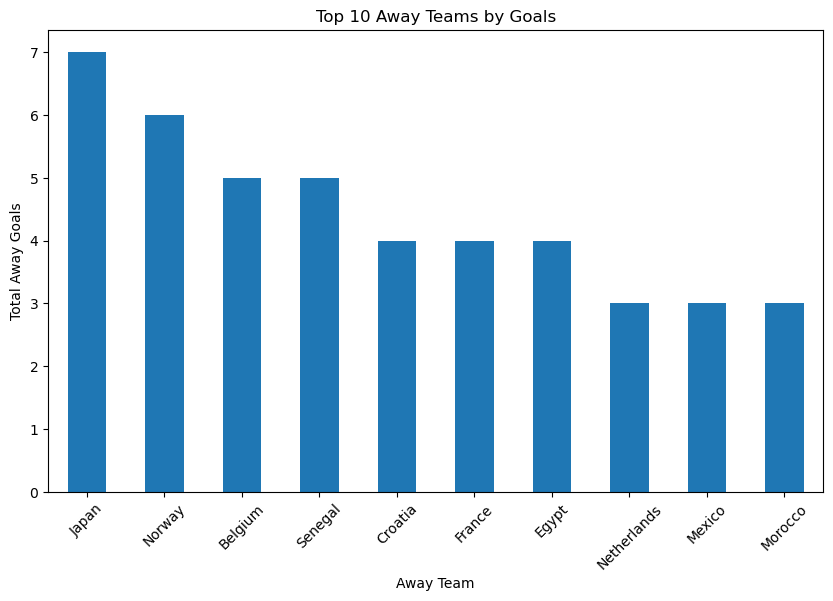

In [31]:
top_away_goals = (
    df.groupby("Away_Team")["away_score"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

top_away_goals.plot(kind="bar")

plt.title("Top 10 Away Teams by Goals")
plt.xlabel("Away Team")
plt.ylabel("Total Away Goals")

plt.xticks(rotation=45)

plt.show()

# Monthly Match Trends
Analyzing matches and goals across different months.

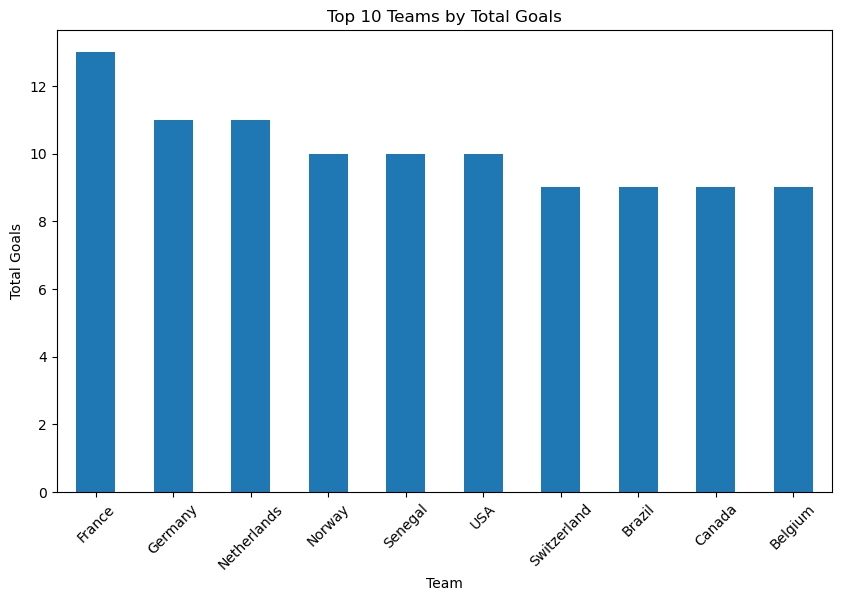

In [32]:
team_goals = (
    df.groupby("Home_Team")["home_score"].sum()
    + df.groupby("Away_Team")["away_score"].sum()
).sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

team_goals.plot(kind="bar")

plt.title("Top 10 Teams by Total Goals")
plt.xlabel("Team")
plt.ylabel("Total Goals")

plt.xticks(rotation=45)

plt.show()

In [33]:
matches_by_month = df["Match_Month"].value_counts().sort_index()
matches_by_month

Match_Month
July    12
June    77
Name: count, dtype: int64

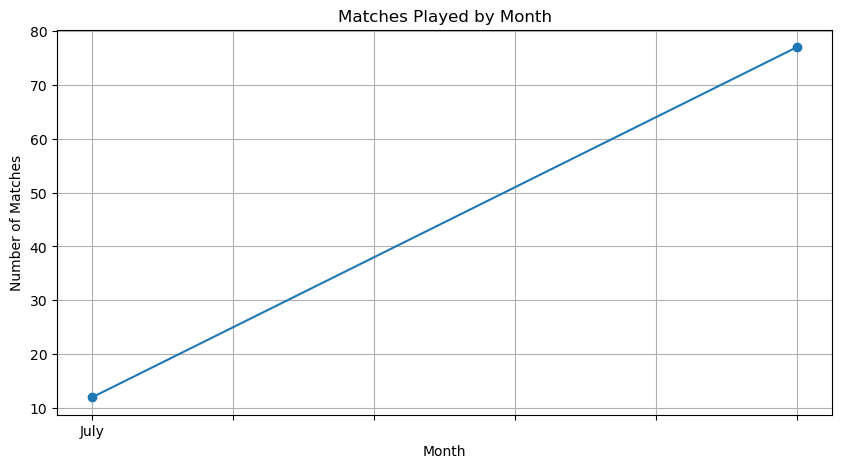

In [34]:
plt.figure(figsize=(10,5))

matches_by_month.plot(
    kind="line",
    marker="o"
)

plt.title("Matches Played by Month")
plt.xlabel("Month")
plt.ylabel("Number of Matches")

plt.grid(True)

plt.show()

In [35]:
goals_by_month = df.groupby("Match_Month")["Total_Goals"].sum()
goals_by_month

Match_Month
July     23
June    226
Name: Total_Goals, dtype: int64

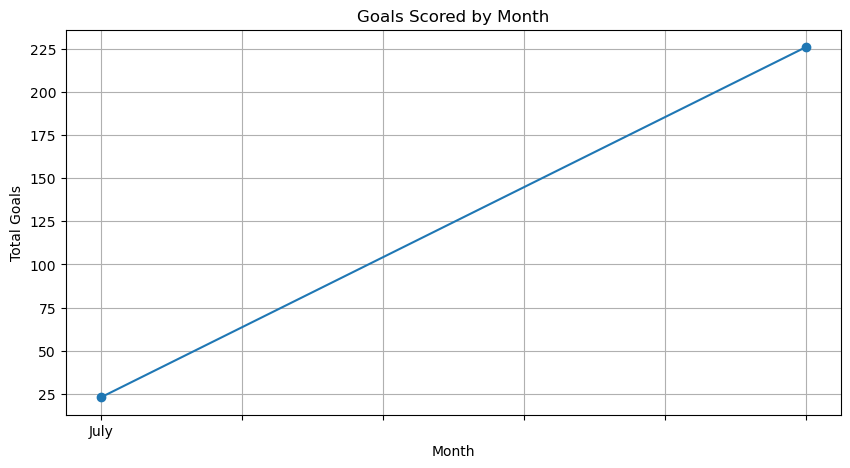

In [36]:
plt.figure(figsize=(10,5))

goals_by_month.plot(
    kind="line",
    marker="o"
)

plt.title("Goals Scored by Month")
plt.xlabel("Month")
plt.ylabel("Total Goals")

plt.grid(True)

plt.show()

In [37]:
avg_goals_month = df.groupby("Match_Month")["Total_Goals"].mean()
avg_goals_month

Match_Month
July    1.916667
June    2.935065
Name: Total_Goals, dtype: float64

# High Scoring Matches
Identifying matches with the highest goal counts.

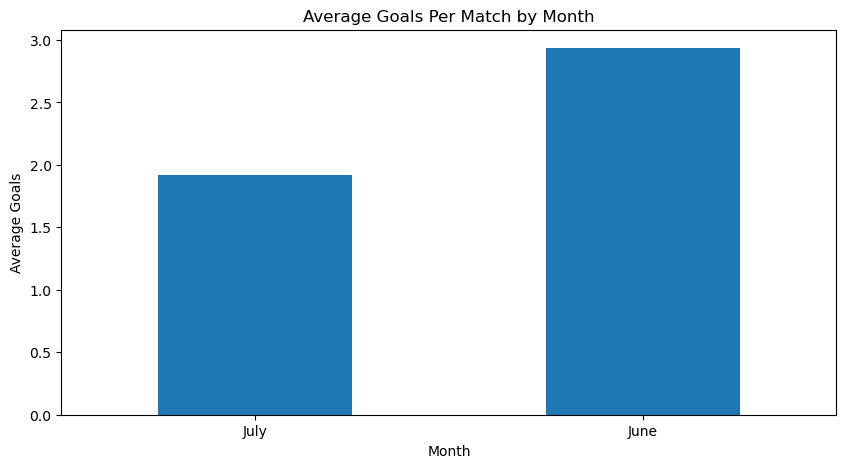

In [38]:
plt.figure(figsize=(10,5))

avg_goals_month.plot(kind="bar")

plt.title("Average Goals Per Match by Month")
plt.xlabel("Month")
plt.ylabel("Average Goals")

plt.xticks(rotation=0)

plt.show()

# Match Outcome Analysis
Analyzing home wins, away wins, and draw statistics.

In [39]:
df.sort_values(
    by="Total_Goals",
    ascending=False
).head(10)

,match_id,date,kickoff_time_utc,stage_id,venue_id,home_team_id,away_team_id,home_score,away_score,status,...,away_xg,referee_id,player_of_the_match_id,Total_Goals,Goal_Difference,Match_Result,Match_Year,Match_Month,Home_Team,Away_Team
8,9,14-06-2026,15:00,1,9,17,18,7.0,1.0,Completed,...,0.44,9,423.0,8,0,Home Win,2026,June,Germany,CuraÃ§ao
11,12,14-06-2026,23:59,1,12,23,24,5.0,1.0,Completed,...,0.78,12,581.0,6,0,Home Win,2026,June,Sweden,Tunisia
60,61,27-06-2026,18:00,1,4,28,25,1.0,5.0,Completed,...,3.25,13,634.0,6,0,Away Win,2026,June,New Zealand,Belgium
21,22,17-06-2026,18:00,1,13,45,46,4.0,2.0,Completed,...,1.64,6,1153.0,6,0,Home Win,2026,June,England,Croatia
53,54,25-06-2026,18:00,1,10,10,11,4.0,2.0,Completed,...,1.12,6,236.0,6,0,Home Win,2026,June,Morocco,Haiti
34,35,20-06-2026,21:00,1,14,21,23,5.0,1.0,Completed,...,0.88,3,531.0,6,0,Home Win,2026,June,Netherlands,Sweden
26,27,18-06-2026,21:00,1,5,5,7,6.0,0.0,Completed,...,0.22,11,114.0,6,0,Home Win,2026,June,Canada,Qatar
67,68,27-06-2026,22:00,1,3,38,39,3.0,3.0,Completed,...,1.44,4,969.0,6,0,Draw,2026,June,Algeria,Austria
41,42,22-06-2026,18:00,1,6,36,34,3.0,2.0,Completed,...,1.48,10,919.0,5,0,Home Win,2026,June,Norway,Senegal
65,66,26-06-2026,18:00,1,2,34,35,5.0,0.0,Completed,...,0.14,2,871.0,5,0,Home Win,2026,June,Senegal,Iraq


In [40]:
home_wins = df[df["Match_Result"] == "Home Win"]
home_wins

,match_id,date,kickoff_time_utc,stage_id,venue_id,home_team_id,away_team_id,home_score,away_score,status,...,away_xg,referee_id,player_of_the_match_id,Total_Goals,Goal_Difference,Match_Result,Match_Year,Match_Month,Home_Team,Away_Team
0,1,11-06-2026,19:00,1,0,1,2,2.0,0.0,Completed,...,0.52,1,16.0,2,0,Home Win,2026,June,Mexico,South Africa
1,2,11-06-2026,23:00,1,7,3,4,2.0,1.0,Completed,...,1.12,2,58.0,3,0,Home Win,2026,June,South Korea,Czechia
3,4,12-06-2026,23:00,1,3,13,14,4.0,1.0,Completed,...,0.88,4,332.0,5,0,Home Win,2026,June,USA,Paraguay
7,8,13-06-2026,23:59,1,16,15,16,2.0,0.0,Completed,...,0.72,8,381.0,2,0,Home Win,2026,June,Australia,TÃ¼rkiye
8,9,14-06-2026,15:00,1,9,17,18,7.0,1.0,Completed,...,0.44,9,423.0,8,0,Home Win,2026,June,Germany,CuraÃ§ao
10,11,14-06-2026,21:00,1,11,19,20,1.0,0.0,Completed,...,0.95,11,479.0,1,0,Home Win,2026,June,CÃ´te d'Ivoire,Ecuador
11,12,14-06-2026,23:59,1,12,23,24,5.0,1.0,Completed,...,0.78,12,581.0,6,0,Home Win,2026,June,Sweden,Tunisia
16,17,16-06-2026,15:00,1,2,33,34,3.0,1.0,Completed,...,1.05,1,843.0,4,0,Home Win,2026,June,France,Senegal
18,19,16-06-2026,21:00,1,3,37,38,3.0,0.0,Completed,...,0.42,3,946.0,3,0,Home Win,2026,June,Argentina,Algeria
19,20,16-06-2026,23:59,1,15,39,40,3.0,1.0,Completed,...,0.88,4,1023.0,4,0,Home Win,2026,June,Austria,Jordan


In [41]:
away_wins = df[df["Match_Result"] == "Away Win"]
away_wins

,match_id,date,kickoff_time_utc,stage_id,venue_id,home_team_id,away_team_id,home_score,away_score,status,...,away_xg,referee_id,player_of_the_match_id,Total_Goals,Goal_Difference,Match_Result,Match_Year,Match_Month,Home_Team,Away_Team
6,7,13-06-2026,21:00,1,14,11,12,0.0,1.0,Completed,...,0.65,7,293.0,1,0,Away Win,2026,June,Haiti,Scotland
17,18,16-06-2026,18:00,1,10,35,36,1.0,4.0,Completed,...,2.85,2,919.0,5,0,Away Win,2026,June,Iraq,Norway
23,24,17-06-2026,23:59,1,16,43,44,1.0,3.0,Completed,...,2.10,8,1125.0,4,0,Away Win,2026,June,Uzbekistan,Colombia
29,30,19-06-2026,18:00,1,4,12,10,0.0,1.0,Completed,...,0.54,14,245.0,1,0,Away Win,2026,June,Scotland,Morocco
31,32,19-06-2026,23:59,1,8,16,14,0.0,1.0,Completed,...,0.30,16,361.0,1,0,Away Win,2026,June,TÃ¼rkiye,Paraguay
35,36,20-06-2026,23:59,1,16,24,22,0.0,4.0,Completed,...,3.12,4,564.0,4,0,Away Win,2026,June,Tunisia,Japan
37,38,21-06-2026,18:00,1,13,28,26,1.0,3.0,Completed,...,2.15,6,660.0,4,0,Away Win,2026,June,New Zealand,Egypt
43,44,22-06-2026,23:59,1,10,40,38,1.0,2.0,Completed,...,1.92,12,984.0,3,0,Away Win,2026,June,Jordan,Algeria
47,48,23-06-2026,23:59,1,1,48,46,0.0,1.0,Completed,...,1.48,16,1181.0,1,0,Away Win,2026,June,Panama,Croatia
48,49,24-06-2026,18:00,1,1,4,1,0.0,3.0,Completed,...,1.27,1,20.0,3,0,Away Win,2026,June,Czechia,Mexico


In [42]:
draw_matches = df[df["Match_Result"] == "Draw"]
draw_matches

,match_id,date,kickoff_time_utc,stage_id,venue_id,home_team_id,away_team_id,home_score,away_score,status,...,away_xg,referee_id,player_of_the_match_id,Total_Goals,Goal_Difference,Match_Result,Match_Year,Match_Month,Home_Team,Away_Team
2,3,12-06-2026,19:00,1,6,5,6,1.0,1.0,Completed,...,0.98,3,112.0,2,0,Draw,2026,June,Canada,Bosnia and Herzegovina
4,5,13-06-2026,15:00,1,10,7,8,1.0,1.0,Completed,...,1.54,5,157.0,2,0,Draw,2026,June,Qatar,Switzerland
5,6,13-06-2026,18:00,1,2,9,10,1.0,1.0,Completed,...,1.10,6,215.0,2,0,Draw,2026,June,Brazil,Morocco
9,10,14-06-2026,18:00,1,15,21,22,2.0,2.0,Completed,...,1.82,10,524.0,4,0,Draw,2026,June,Netherlands,Japan
12,13,15-06-2026,15:00,1,13,29,30,0.0,0.0,Completed,...,0.35,13,755.0,0,0,Draw,2026,June,Spain,Cabo Verde
13,14,15-06-2026,18:00,1,4,25,26,1.0,1.0,Completed,...,1.12,14,658.0,2,0,Draw,2026,June,Belgium,Egypt
14,15,15-06-2026,21:00,1,8,31,32,1.0,1.0,Completed,...,1.76,15,801.0,2,0,Draw,2026,June,Saudi Arabia,Uruguay
15,16,15-06-2026,23:59,1,5,27,28,2.0,2.0,Completed,...,1.20,16,699.0,4,0,Draw,2026,June,IR Iran,New Zealand
20,21,17-06-2026,15:00,1,9,41,42,1.0,1.0,Completed,...,1.15,5,1055.0,2,0,Draw,2026,June,Portugal,Congo DR
25,26,18-06-2026,18:00,1,3,4,2,1.0,1.0,Completed,...,1.15,10,96.0,2,0,Draw,2026,June,Czechia,South Africa


In [43]:
print("Home Wins :", len(home_wins))
print("Away Wins :", len(away_wins))
print("Draws :", len(draw_matches))

Home Wins : 43
Away Wins : 20
Draws : 26


In [44]:
home_wins["Home_Team"].value_counts().head(10)

Home_Team
Mexico         3
USA            3
Switzerland    3
France         3
Argentina      2
Portugal       2
Spain          2
England        2
Brazil         2
Germany        2
Name: count, dtype: int64

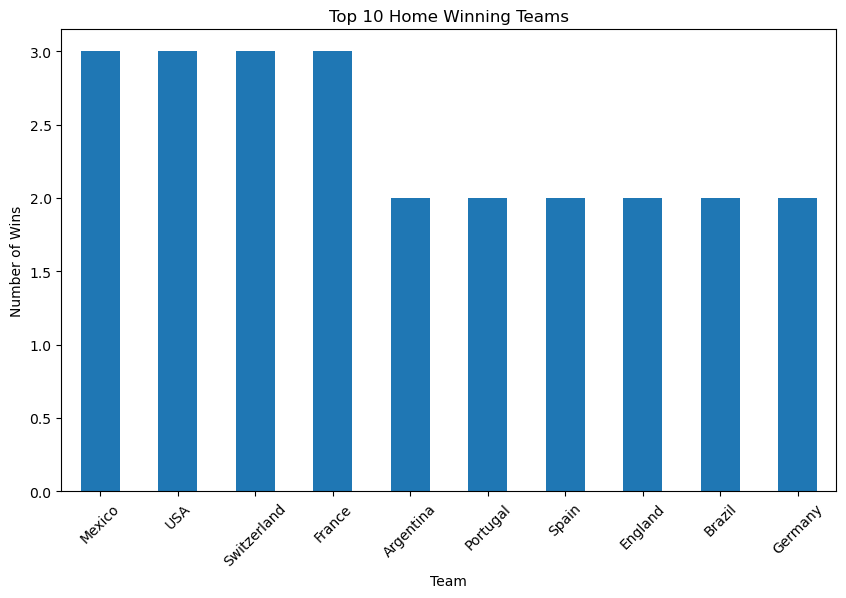

In [45]:
plt.figure(figsize=(10,6))

home_wins["Home_Team"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Home Winning Teams")
plt.xlabel("Team")
plt.ylabel("Number of Wins")

plt.xticks(rotation=45)

plt.show()

In [46]:
away_wins["Away_Team"].value_counts().head(10)

Away_Team
Norway            2
Scotland          1
Brazil            1
England           1
Argentina         1
France            1
Spain             1
Belgium           1
Netherlands       1
CÃ´te d'Ivoire    1
Name: count, dtype: int64

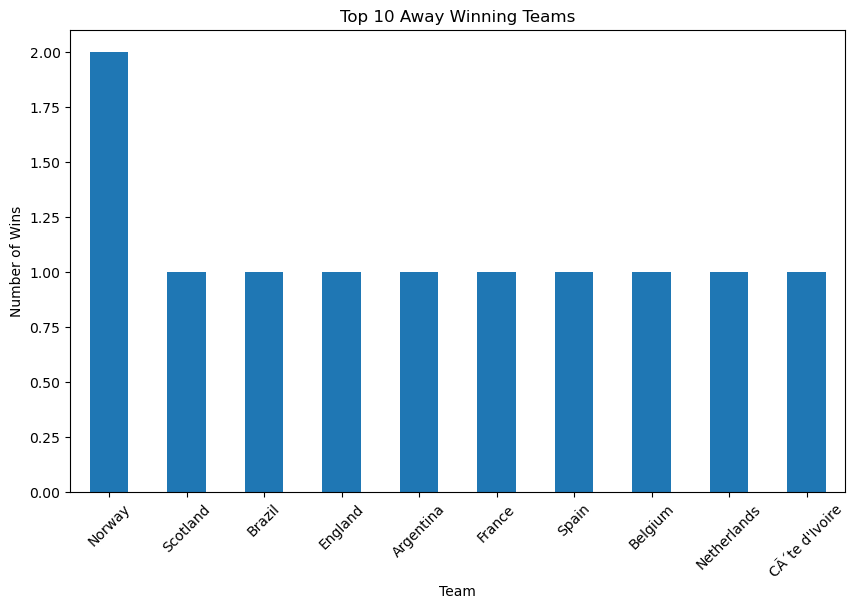

In [47]:
plt.figure(figsize=(10,6))

away_wins["Away_Team"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Away Winning Teams")
plt.xlabel("Team")
plt.ylabel("Number of Wins")

plt.xticks(rotation=45)

plt.show()

In [48]:
print("Average Home Goals :", df["home_score"].mean())
print("Average Away Goals :", df["away_score"].mean())

Average Home Goals : 1.8
Average Away Goals : 1.1294117647058823


# Correlation Analysis
Examining relationships between numerical football statistics.

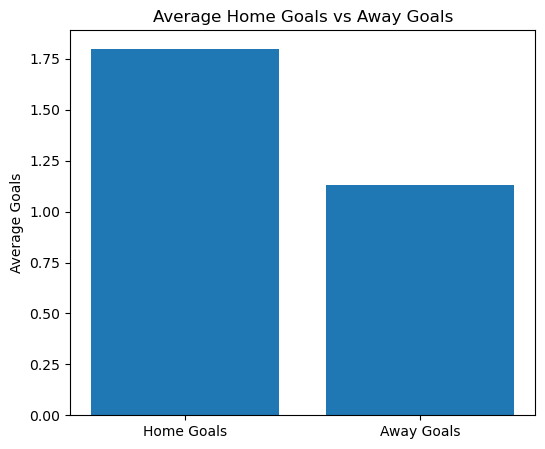

In [49]:
avg_goals = {
    "Home Goals": df["home_score"].mean(),
    "Away Goals": df["away_score"].mean()
}

plt.figure(figsize=(6,5))

plt.bar(avg_goals.keys(), avg_goals.values())

plt.title("Average Home Goals vs Away Goals")
plt.ylabel("Average Goals")

plt.show()

In [50]:
correlation = df.corr(numeric_only=True)
correlation

,match_id,stage_id,venue_id,home_team_id,away_team_id,home_score,away_score,home_xg,away_xg,referee_id,player_of_the_match_id,Total_Goals,Goal_Difference,Match_Year
match_id,1.000000,0.669193,0.010795,0.184552,0.255808,-0.106577,0.077283,-0.206712,0.063006,0.047847,0.161815,-0.157946,NaN,NaN
stage_id,0.669193,1.000000,-0.045456,-0.115031,0.033907,0.012672,-0.134796,-0.000716,-0.015730,0.042265,-0.135878,-0.234950,NaN,NaN
venue_id,0.010795,-0.045456,1.000000,0.283805,0.249326,-0.129970,0.016619,-0.090253,0.078784,-0.001537,0.265698,-0.119404,NaN,NaN
home_team_id,0.184552,-0.115031,0.283805,1.000000,0.923261,-0.015655,0.143019,0.065230,0.110020,0.116406,0.982573,0.064893,NaN,NaN
away_team_id,0.255808,0.033907,0.249326,0.923261,1.000000,0.035630,0.066229,0.139471,0.081231,0.102151,0.943850,0.045679,NaN,NaN
home_score,-0.106577,0.012672,-0.129970,-0.015655,0.035630,1.000000,-0.166037,0.834974,-0.239319,-0.143295,0.004207,0.771836,NaN,NaN
away_score,0.077283,-0.134796,0.016619,0.143019,0.066229,-0.166037,1.000000,-0.333346,0.783224,-0.164122,0.123423,0.498842,NaN,NaN
home_xg,-0.206712,-0.000716,-0.090253,0.065230,0.139471,0.834974,-0.333346,1.000000,-0.421552,-0.155715,0.085446,0.518921,NaN,NaN
away_xg,0.063006,-0.015730,0.078784,0.110020,0.081231,-0.239319,0.783224,-0.421552,1.000000,-0.109697,0.115493,0.294665,NaN,NaN
referee_id,0.047847,0.042265,-0.001537,0.116406,0.102151,-0.143295,-0.164122,-0.155715,-0.109697,1.000000,0.105331,-0.207972,NaN,NaN


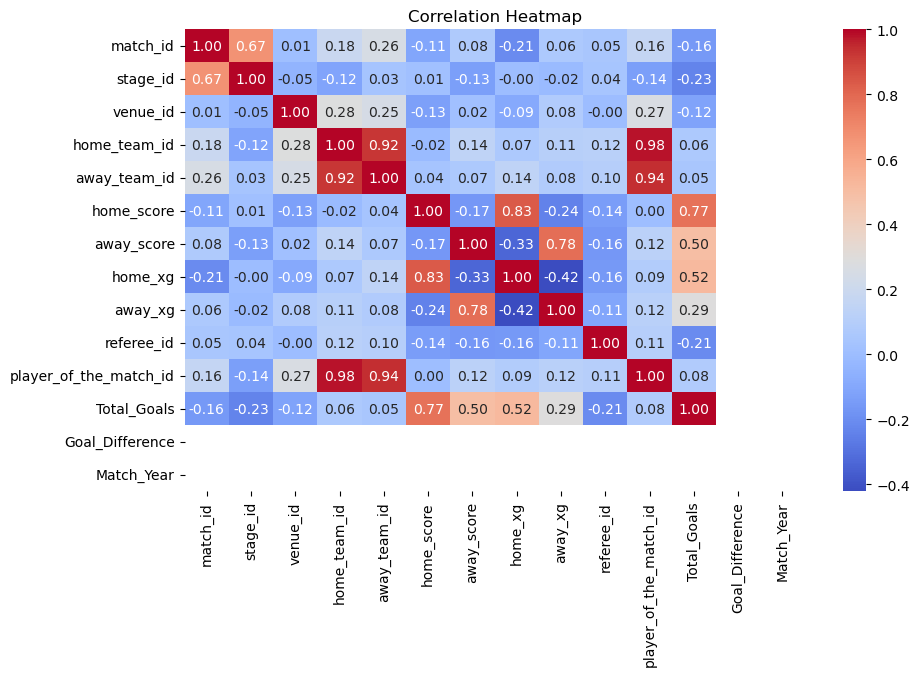

In [51]:
plt.figure(figsize=(10,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

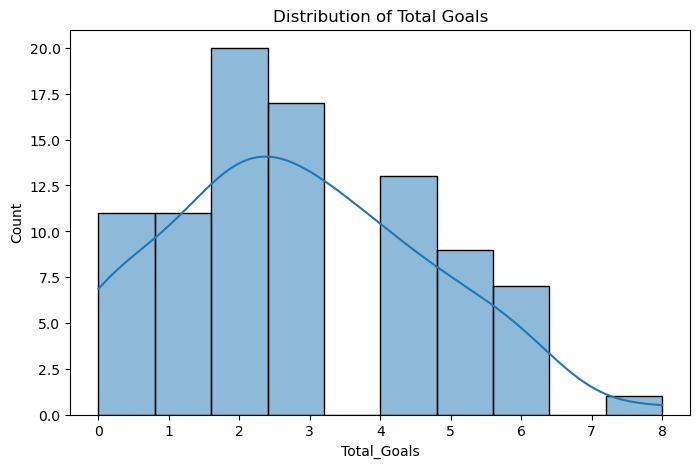

In [52]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Total_Goals"],
    bins=10,
    kde=True
)

plt.title("Distribution of Total Goals")

plt.show()

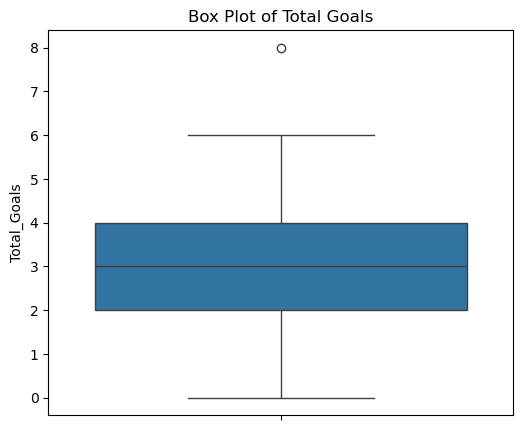

In [53]:
plt.figure(figsize=(6,5))

sns.boxplot(
    y=df["Total_Goals"]
)

plt.title("Box Plot of Total Goals")

plt.show()

In [54]:
df.sort_values(
    by="Goal_Difference",
    ascending=False
).head(10)

,match_id,date,kickoff_time_utc,stage_id,venue_id,home_team_id,away_team_id,home_score,away_score,status,...,away_xg,referee_id,player_of_the_match_id,Total_Goals,Goal_Difference,Match_Result,Match_Year,Match_Month,Home_Team,Away_Team
0,1,11-06-2026,19:00,1,0,1,2,2.0,0.0,Completed,...,0.52,1,16.0,2,0,Home Win,2026,June,Mexico,South Africa
45,46,23-06-2026,18:00,1,14,44,42,1.0,0.0,Completed,...,0.58,14,1120.0,1,0,Home Win,2026,June,Colombia,Congo DR
65,66,26-06-2026,18:00,1,2,34,35,5.0,0.0,Completed,...,0.14,2,871.0,5,0,Home Win,2026,June,Senegal,Iraq
64,65,26-06-2026,18:00,1,10,36,33,1.0,4.0,Completed,...,0.96,1,839.0,5,0,Away Win,2026,June,Norway,France
63,64,27-06-2026,22:00,1,14,30,31,0.0,0.0,Completed,...,0.38,16,755.0,0,0,Draw,2026,June,Cabo Verde,Saudi Arabia
62,63,27-06-2026,22:00,1,13,32,29,0.0,1.0,Completed,...,1.35,15,743.0,1,0,Away Win,2026,June,Uruguay,Spain
61,62,27-06-2026,18:00,1,8,26,27,1.0,1.0,Completed,...,0.92,14,699.0,2,0,Draw,2026,June,Egypt,IR Iran
60,61,27-06-2026,18:00,1,4,28,25,1.0,5.0,Completed,...,3.25,13,634.0,6,0,Away Win,2026,June,New Zealand,Belgium
59,60,26-06-2026,22:00,1,16,22,23,1.0,1.0,Completed,...,0.95,12,557.0,2,0,Draw,2026,June,Japan,Sweden
58,59,26-06-2026,22:00,1,12,24,21,1.0,3.0,Completed,...,2.15,11,539.0,4,0,Away Win,2026,June,Tunisia,Netherlands


In [55]:
df.groupby("Match_Year")["Total_Goals"].mean()

Match_Year
2026    2.797753
Name: Total_Goals, dtype: float64

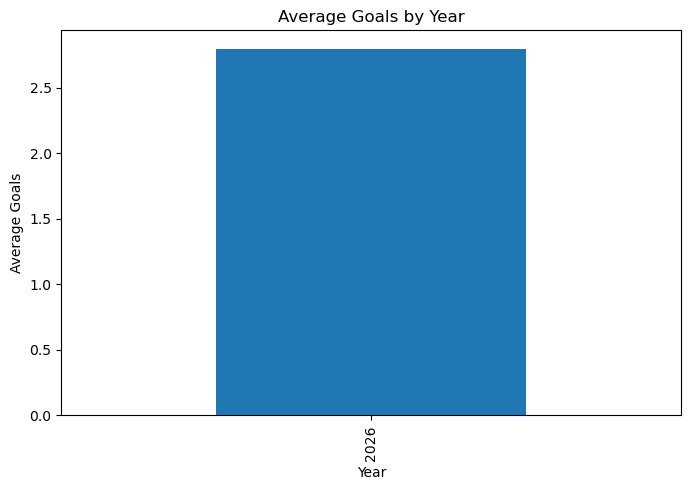

In [56]:
plt.figure(figsize=(8,5))

df.groupby("Match_Year")["Total_Goals"].mean().plot(
    kind="bar"
)

plt.title("Average Goals by Year")
plt.xlabel("Year")
plt.ylabel("Average Goals")

plt.show()

# Exporting Processed Dataset
Saving the cleaned and enriched football dataset.

In [57]:
df.head()

,match_id,date,kickoff_time_utc,stage_id,venue_id,home_team_id,away_team_id,home_score,away_score,status,...,away_xg,referee_id,player_of_the_match_id,Total_Goals,Goal_Difference,Match_Result,Match_Year,Match_Month,Home_Team,Away_Team
0,1,11-06-2026,19:00,1,0,1,2,2.0,0.0,Completed,...,0.52,1,16.0,2,0,Home Win,2026,June,Mexico,South Africa
1,2,11-06-2026,23:00,1,7,3,4,2.0,1.0,Completed,...,1.12,2,58.0,3,0,Home Win,2026,June,South Korea,Czechia
2,3,12-06-2026,19:00,1,6,5,6,1.0,1.0,Completed,...,0.98,3,112.0,2,0,Draw,2026,June,Canada,Bosnia and Herzegovina
3,4,12-06-2026,23:00,1,3,13,14,4.0,1.0,Completed,...,0.88,4,332.0,5,0,Home Win,2026,June,USA,Paraguay
4,5,13-06-2026,15:00,1,10,7,8,1.0,1.0,Completed,...,1.54,5,157.0,2,0,Draw,2026,June,Qatar,Switzerland


# Feature Engineering
Creating new football performance metrics and analytical features.

In [58]:
df.to_csv(
    "football_final_dataset.csv",
    index=False
)

In [59]:
def goal_category(goals):
    
    if goals <= 2:
        return "Low Scoring"

    elif goals <= 5:
        return "Medium Scoring"

    else:
        return "High Scoring"

In [60]:
df["Goal_Category"] = df["Total_Goals"].apply(goal_category)

In [61]:
df[["Total_Goals","Goal_Category"]].head(10)

,Total_Goals,Goal_Category
0,2,Low Scoring
1,3,Medium Scoring
2,2,Low Scoring
3,5,Medium Scoring
4,2,Low Scoring
5,2,Low Scoring
6,1,Low Scoring
7,2,Low Scoring
8,8,High Scoring
9,4,Medium Scoring


In [62]:
df["Goal_Category"].value_counts()

Goal_Category
Low Scoring       42
Medium Scoring    39
High Scoring       8
Name: count, dtype: int64

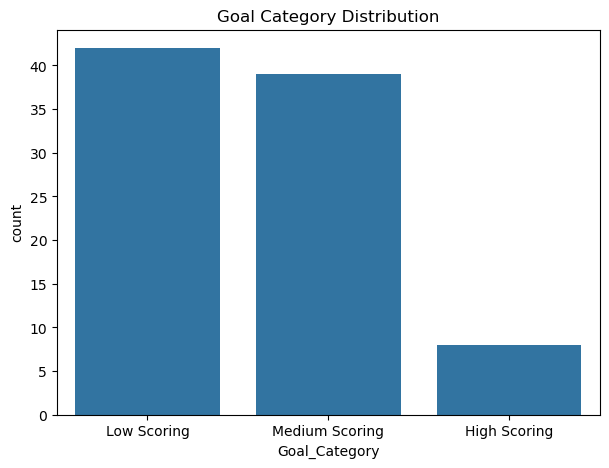

In [63]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Goal_Category"
)

plt.title("Goal Category Distribution")

plt.show()

In [64]:
df["Winning_Margin"] = abs(df["Goal_Difference"])

In [65]:
df[
[
"home_score",
"away_score",
"Winning_Margin"
]
].head()

,home_score,away_score,Winning_Margin
0,2.0,0.0,0
1,2.0,1.0,0
2,1.0,1.0,0
3,4.0,1.0,0
4,1.0,1.0,0


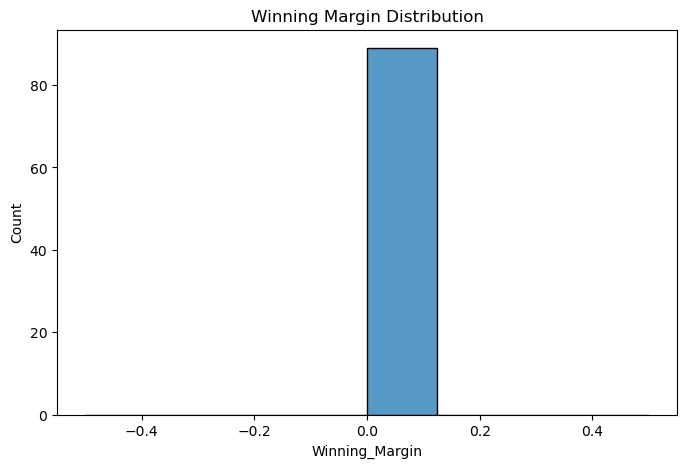

In [66]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Winning_Margin"],
    bins=8
)

plt.title("Winning Margin Distribution")

plt.show()

In [67]:
df["High_Scoring_Match"] = df["Total_Goals"].apply(

lambda x:

"Yes"

if x>=5

else

"No"

)

In [68]:
df["High_Scoring_Match"].value_counts()

High_Scoring_Match
No     72
Yes    17
Name: count, dtype: int64

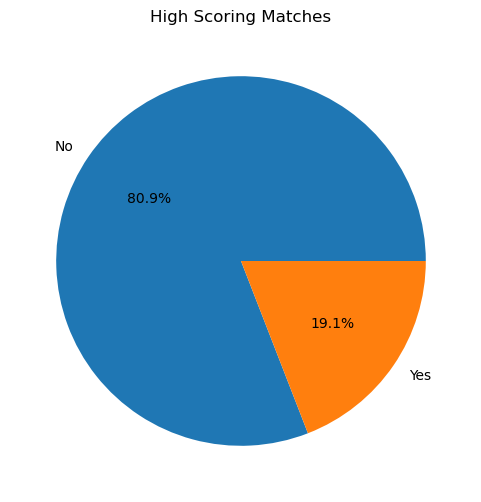

In [69]:
plt.figure(figsize=(6,6))

df["High_Scoring_Match"].value_counts().plot(

kind="pie",

autopct="%1.1f%%"

)

plt.title("High Scoring Matches")

plt.ylabel("")

plt.show()

In [71]:
def attack_rating(goals):

    if goals <= 1:
        return "Poor"

    elif goals <= 3:
        return "Average"

    else:
        return "Strong"

In [72]:
df["Home_Attack_Rating"] = df["home_score"].apply(attack_rating)

df["Away_Attack_Rating"] = df["away_score"].apply(attack_rating)

In [73]:
df[[
    "Home_Team",
    "home_score",
    "Home_Attack_Rating",
    "Away_Team",
    "away_score",
    "Away_Attack_Rating"
]].head(10)

,Home_Team,home_score,Home_Attack_Rating,Away_Team,away_score,Away_Attack_Rating
0,Mexico,2.0,Average,South Africa,0.0,Poor
1,South Korea,2.0,Average,Czechia,1.0,Poor
2,Canada,1.0,Poor,Bosnia and Herzegovina,1.0,Poor
3,USA,4.0,Strong,Paraguay,1.0,Poor
4,Qatar,1.0,Poor,Switzerland,1.0,Poor
5,Brazil,1.0,Poor,Morocco,1.0,Poor
6,Haiti,0.0,Poor,Scotland,1.0,Poor
7,Australia,2.0,Average,TÃ¼rkiye,0.0,Poor
8,Germany,7.0,Strong,CuraÃ§ao,1.0,Poor
9,Netherlands,2.0,Average,Japan,2.0,Average


In [74]:
def defense_rating(goals_conceded):

    if goals_conceded == 0:
        return "Excellent"

    elif goals_conceded <= 2:
        return "Good"

    else:
        return "Weak"

In [75]:
df["Home_Defense_Rating"] = df["away_score"].apply(defense_rating)

df["Away_Defense_Rating"] = df["home_score"].apply(defense_rating)

In [76]:
df[[
    "Home_Team",
    "home_score",
    "away_score",
    "Home_Defense_Rating",
    "Away_Team",
    "Away_Defense_Rating"
]].head(10)

,Home_Team,home_score,away_score,Home_Defense_Rating,Away_Team,Away_Defense_Rating
0,Mexico,2.0,0.0,Excellent,South Africa,Good
1,South Korea,2.0,1.0,Good,Czechia,Good
2,Canada,1.0,1.0,Good,Bosnia and Herzegovina,Good
3,USA,4.0,1.0,Good,Paraguay,Weak
4,Qatar,1.0,1.0,Good,Switzerland,Good
5,Brazil,1.0,1.0,Good,Morocco,Good
6,Haiti,0.0,1.0,Good,Scotland,Excellent
7,Australia,2.0,0.0,Excellent,TÃ¼rkiye,Good
8,Germany,7.0,1.0,Good,CuraÃ§ao,Weak
9,Netherlands,2.0,2.0,Good,Japan,Good


In [77]:
df["Home_Defense_Rating"].value_counts()

Home_Defense_Rating
Good         46
Excellent    28
Weak         15
Name: count, dtype: int64

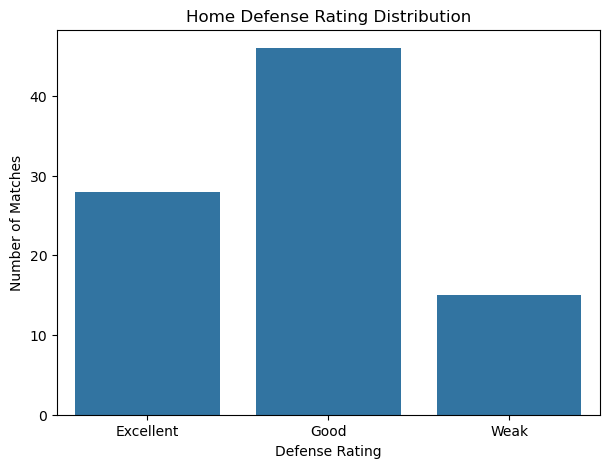

In [78]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Home_Defense_Rating",
    order=["Excellent", "Good", "Weak"]
)

plt.title("Home Defense Rating Distribution")
plt.xlabel("Defense Rating")
plt.ylabel("Number of Matches")

plt.show()

In [79]:
df["Home_Goal_Efficiency"] = (
    df["home_score"] / df["home_xg"]
).round(2)

df["Away_Goal_Efficiency"] = (
    df["away_score"] / df["away_xg"]
).round(2)

In [80]:
df[[
    "home_score",
    "home_xg",
    "Home_Goal_Efficiency",
    "away_score",
    "away_xg",
    "Away_Goal_Efficiency"
]].head(10)

,home_score,home_xg,Home_Goal_Efficiency,away_score,away_xg,Away_Goal_Efficiency
0,2.0,1.84,1.09,0.0,0.52,0.00
1,2.0,1.45,1.38,1.0,1.12,0.89
2,1.0,1.35,0.74,1.0,0.98,1.02
3,4.0,2.76,1.45,1.0,0.88,1.14
4,1.0,0.78,1.28,1.0,1.54,0.65
5,1.0,1.62,0.62,1.0,1.10,0.91
6,0.0,1.25,0.00,1.0,0.65,1.54
7,2.0,1.48,1.35,0.0,0.72,0.00
8,7.0,4.82,1.45,1.0,0.44,2.27
9,2.0,1.95,1.03,2.0,1.82,1.10


In [81]:
df["Home_Goal_Efficiency"].describe()

count    85.000000
mean      1.107412
std       0.862238
min       0.000000
25%       0.620000
50%       1.130000
75%       1.520000
max       4.760000
Name: Home_Goal_Efficiency, dtype: float64

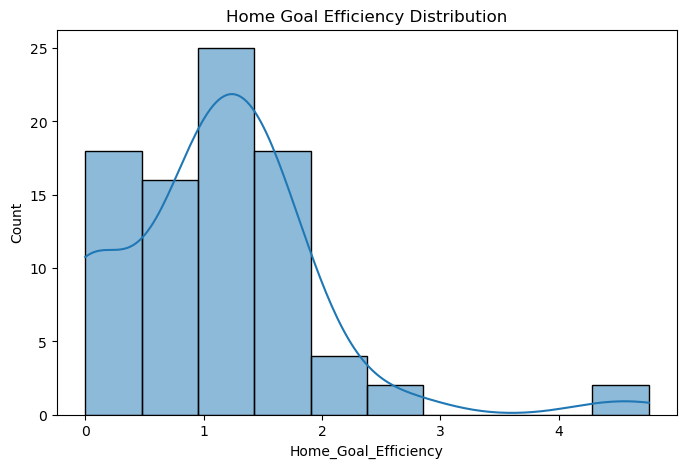

In [82]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Home_Goal_Efficiency"],
    bins=10,
    kde=True
)

plt.title("Home Goal Efficiency Distribution")

plt.show()

In [83]:
def match_intensity(goals):

    if goals <= 2:
        return "Low"

    elif goals <= 5:
        return "Medium"

    else:
        return "High"

In [84]:
df["Match_Intensity"] = df["Total_Goals"].apply(match_intensity)

# Advanced Team Performance Analysis
Analyzing team performance using engineered football metrics.

In [85]:
df["Match_Intensity"].value_counts()

Match_Intensity
Low       42
Medium    39
High       8
Name: count, dtype: int64

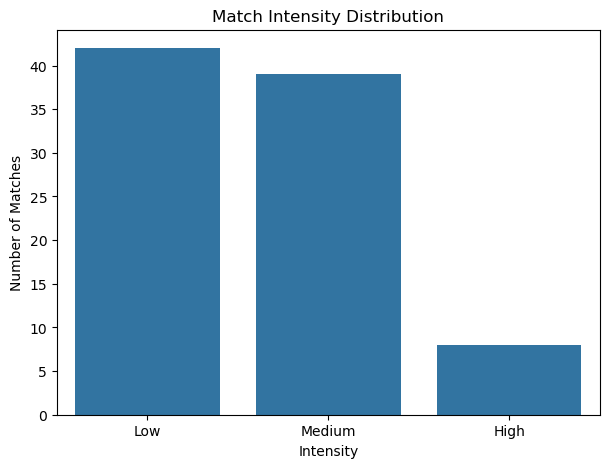

In [86]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Match_Intensity",
    order=["Low", "Medium", "High"]
)

plt.title("Match Intensity Distribution")
plt.xlabel("Intensity")
plt.ylabel("Number of Matches")

plt.show()

In [87]:
team_goals = (
    df.groupby("Home_Team")["home_score"].sum()
    .add(df.groupby("Away_Team")["away_score"].sum(), fill_value=0)
    .sort_values(ascending=False)
)

team_goals.head(10)

Home_Team
France         13.0
Germany        11.0
Netherlands    11.0
Norway         10.0
Senegal        10.0
USA            10.0
Switzerland     9.0
Brazil          9.0
Canada          9.0
Belgium         9.0
dtype: float64

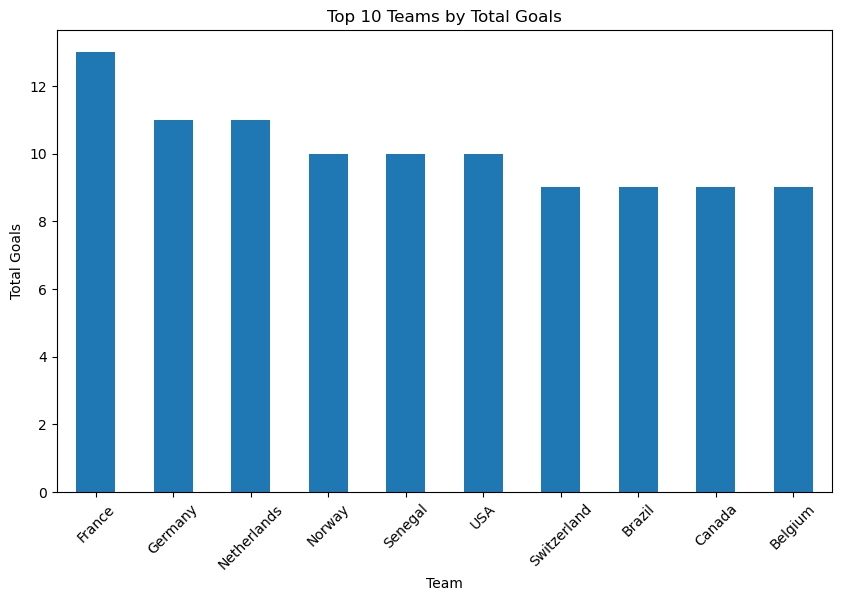

In [88]:
plt.figure(figsize=(10,6))

team_goals.head(10).plot(kind="bar")

plt.title("Top 10 Teams by Total Goals")
plt.xlabel("Team")
plt.ylabel("Total Goals")

plt.xticks(rotation=45)

plt.show()

In [89]:
home_wins = (
    df[df["Match_Result"]=="Home Win"]
    ["Home_Team"]
    .value_counts()
)

home_wins.head(10)

Home_Team
Mexico         3
USA            3
Switzerland    3
France         3
Argentina      2
Portugal       2
Spain          2
England        2
Brazil         2
Germany        2
Name: count, dtype: int64

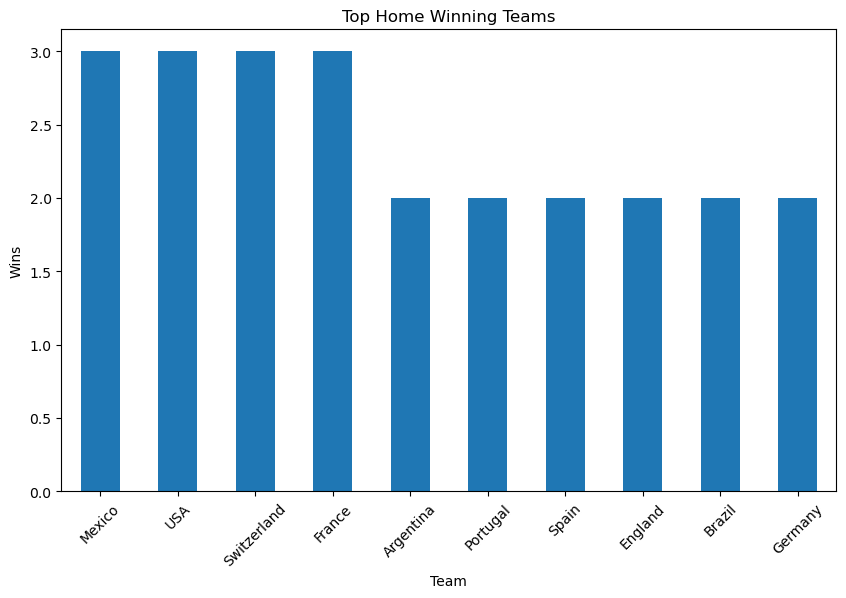

In [90]:
plt.figure(figsize=(10,6))

home_wins.head(10).plot(kind="bar")

plt.title("Top Home Winning Teams")

plt.xlabel("Team")
plt.ylabel("Wins")

plt.xticks(rotation=45)

plt.show()

In [91]:
away_wins = (
    df[df["Match_Result"]=="Away Win"]
    ["Away_Team"]
    .value_counts()
)

away_wins.head(10)

Away_Team
Norway            2
Scotland          1
Brazil            1
England           1
Argentina         1
France            1
Spain             1
Belgium           1
Netherlands       1
CÃ´te d'Ivoire    1
Name: count, dtype: int64

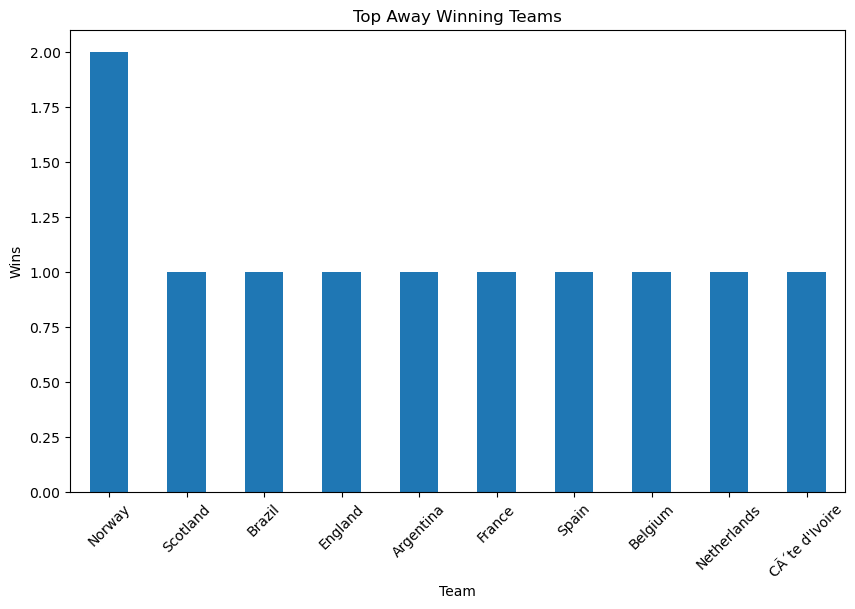

In [92]:
plt.figure(figsize=(10,6))

away_wins.head(10).plot(kind="bar")

plt.title("Top Away Winning Teams")

plt.xlabel("Team")
plt.ylabel("Wins")

plt.xticks(rotation=45)

plt.show()

In [93]:
df[
[
    "Home_Team",
    "Away_Team",
    "home_score",
    "away_score",
    "Total_Goals"
]
].sort_values(
    by="Total_Goals",
    ascending=False
).head(10)

,Home_Team,Away_Team,home_score,away_score,Total_Goals
8,Germany,CuraÃ§ao,7.0,1.0,8
11,Sweden,Tunisia,5.0,1.0,6
60,New Zealand,Belgium,1.0,5.0,6
21,England,Croatia,4.0,2.0,6
53,Morocco,Haiti,4.0,2.0,6
34,Netherlands,Sweden,5.0,1.0,6
26,Canada,Qatar,6.0,0.0,6
67,Algeria,Austria,3.0,3.0,6
41,Norway,Senegal,3.0,2.0,5
65,Senegal,Iraq,5.0,0.0,5


In [94]:
df.groupby("Home_Team")["home_score"].mean().sort_values(
    ascending=False
).head(10)

Home_Team
Sweden                    5.000000
Senegal                   5.000000
Morocco                   4.000000
Canada                    3.500000
Germany                   3.333333
France                    3.000000
Congo DR                  3.000000
Algeria                   3.000000
Bosnia and Herzegovina    3.000000
Austria                   3.000000
Name: home_score, dtype: float64

In [95]:
df.groupby("Away_Team")["away_score"].mean().sort_values(
    ascending=False
).head(10)

Away_Team
Belgium        5.000000
France         4.000000
Norway         3.000000
Colombia       3.000000
Netherlands    3.000000
Mexico         3.000000
Argentina      3.000000
Brazil         3.000000
Japan          2.333333
New Zealand    2.000000
Name: away_score, dtype: float64

In [96]:
total_matches = len(df)

completed_matches = len(df[df["status"] == "Completed"])

scheduled_matches = len(df[df["status"] == "Scheduled"])

total_goals = df["Total_Goals"].sum()

avg_goals = round(df["Total_Goals"].mean(), 2)

print("Total Matches :", total_matches)
print("Completed Matches :", completed_matches)
print("Scheduled Matches :", scheduled_matches)
print("Total Goals :", total_goals)
print("Average Goals Per Match :", avg_goals)

Total Matches : 89
Completed Matches : 85
Scheduled Matches : 4
Total Goals : 249
Average Goals Per Match : 2.8


In [97]:
top_margin = df.sort_values(
    by="Winning_Margin",
    ascending=False
)

top_margin[[
    "Home_Team",
    "Away_Team",
    "Winning_Margin"
]].head(10)

,Home_Team,Away_Team,Winning_Margin
0,Mexico,South Africa,0
45,Colombia,Congo DR,0
65,Senegal,Iraq,0
64,Norway,France,0
63,Cabo Verde,Saudi Arabia,0
62,Uruguay,Spain,0
61,Egypt,IR Iran,0
60,New Zealand,Belgium,0
59,Japan,Sweden,0
58,Tunisia,Netherlands,0


<Figure size 1000x500 with 0 Axes>

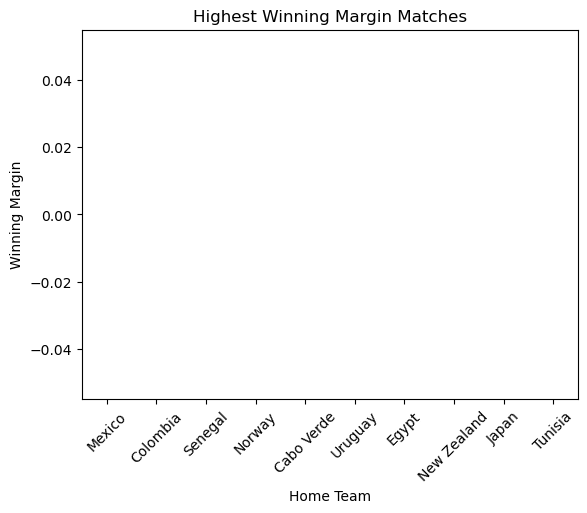

In [98]:
plt.figure(figsize=(10,5))

top_margin.head(10).plot(
    x="Home_Team",
    y="Winning_Margin",
    kind="bar",
    legend=False
)

plt.title("Highest Winning Margin Matches")
plt.xlabel("Home Team")
plt.ylabel("Winning Margin")

plt.xticks(rotation=45)

plt.show()

In [99]:
goal_category = df["Goal_Category"].value_counts()

goal_category

Goal_Category
Low Scoring       42
Medium Scoring    39
High Scoring       8
Name: count, dtype: int64

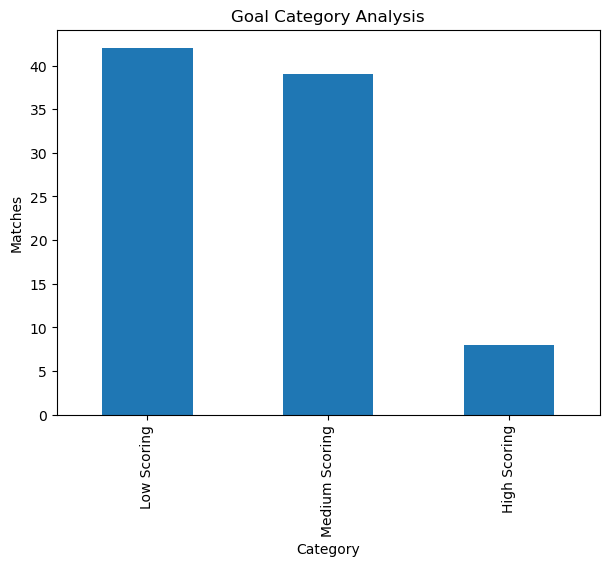

In [100]:
plt.figure(figsize=(7,5))

goal_category.plot(kind="bar")

plt.title("Goal Category Analysis")
plt.xlabel("Category")
plt.ylabel("Matches")

plt.show()

In [101]:
match_intensity = df["Match_Intensity"].value_counts()

match_intensity

Match_Intensity
Low       42
Medium    39
High       8
Name: count, dtype: int64

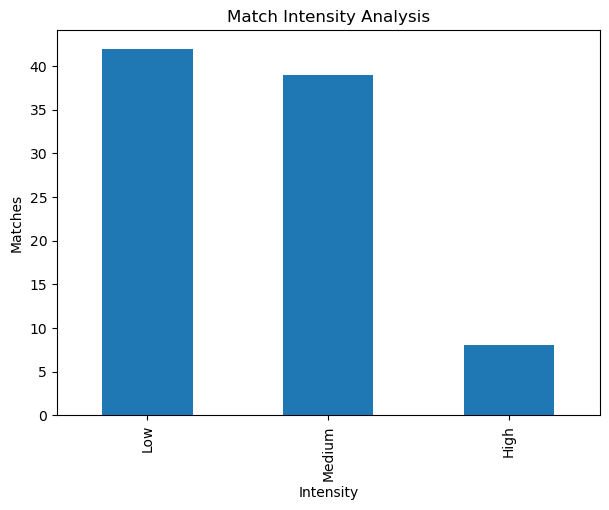

In [102]:
plt.figure(figsize=(7,5))

match_intensity.plot(kind="bar")

plt.title("Match Intensity Analysis")
plt.xlabel("Intensity")
plt.ylabel("Matches")

plt.show()

In [103]:
df["Home_Attack_Rating"].value_counts()

Home_Attack_Rating
Poor       43
Average    31
Strong     15
Name: count, dtype: int64

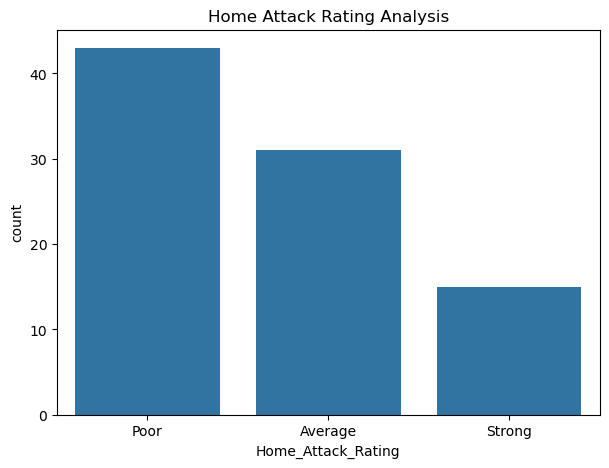

In [104]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Home_Attack_Rating",
    order=["Poor","Average","Strong"]
)

plt.title("Home Attack Rating Analysis")

plt.show()

In [105]:
df["Home_Defense_Rating"].value_counts()

Home_Defense_Rating
Good         46
Excellent    28
Weak         15
Name: count, dtype: int64

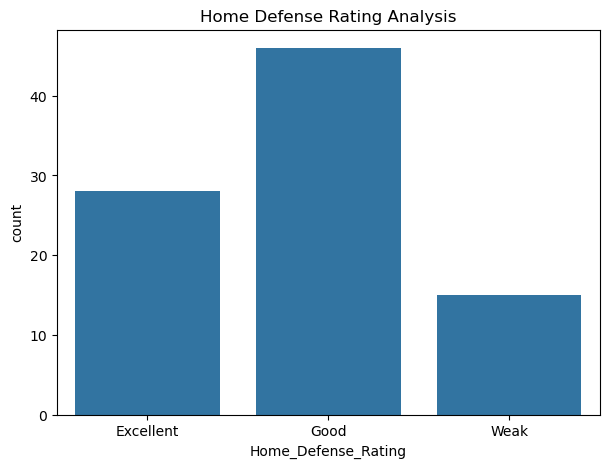

In [106]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Home_Defense_Rating",
    order=["Excellent","Good","Weak"]
)

plt.title("Home Defense Rating Analysis")

plt.show()

In [107]:
print(top_margin.head(10))
print(top_margin.shape)

    match_id        date kickoff_time_utc  stage_id  venue_id  home_team_id  \
0          1  11-06-2026            19:00         1         0             1   
45        46  23-06-2026            18:00         1        14            44   
65        66  26-06-2026            18:00         1         2            34   
64        65  26-06-2026            18:00         1        10            36   
63        64  27-06-2026            22:00         1        14            30   
62        63  27-06-2026            22:00         1        13            32   
61        62  27-06-2026            18:00         1         8            26   
60        61  27-06-2026            18:00         1         4            28   
59        60  26-06-2026            22:00         1        16            22   
58        59  26-06-2026            22:00         1        12            24   

    away_team_id  home_score  away_score     status  ...   Goal_Category  \
0              2         2.0         0.0  Completed  .

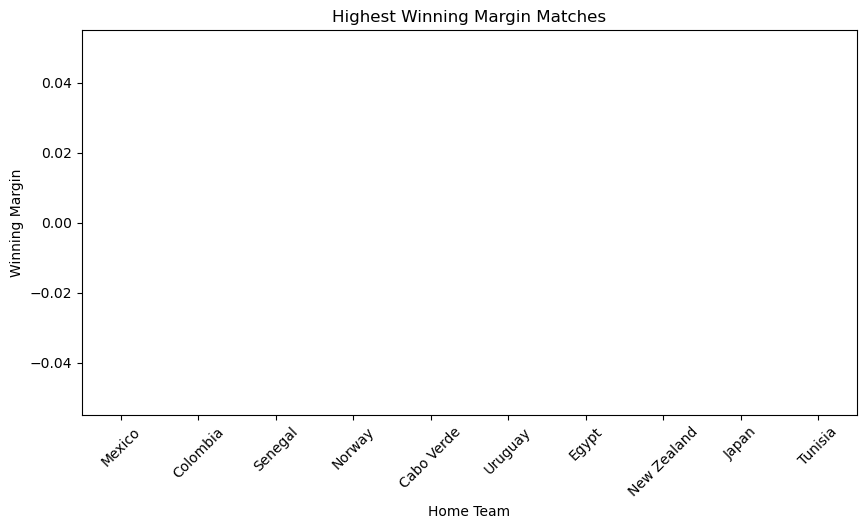

In [108]:
ax = top_margin.head(10).plot(
    x="Home_Team",
    y="Winning_Margin",
    kind="bar",
    figsize=(10,5),
    legend=False
)

ax.set_title("Highest Winning Margin Matches")
ax.set_xlabel("Home Team")
ax.set_ylabel("Winning Margin")
plt.xticks(rotation=45)

plt.show()

In [109]:
print(top_margin[["Home_Team", "Winning_Margin"]].head(10))
print(top_margin["Winning_Margin"].dtype)

      Home_Team  Winning_Margin
0        Mexico               0
45     Colombia               0
65      Senegal               0
64       Norway               0
63   Cabo Verde               0
62      Uruguay               0
61        Egypt               0
60  New Zealand               0
59        Japan               0
58      Tunisia               0
int64


In [110]:
print(df.columns)

Index(['match_id', 'date', 'kickoff_time_utc', 'stage_id', 'venue_id',
       'home_team_id', 'away_team_id', 'home_score', 'away_score', 'status',
       'home_xg', 'away_xg', 'referee_id', 'player_of_the_match_id',
       'Total_Goals', 'Goal_Difference', 'Match_Result', 'Match_Year',
       'Match_Month', 'Home_Team', 'Away_Team', 'Goal_Category',
       'Winning_Margin', 'High_Scoring_Match', 'Home_Attack_Rating',
       'Away_Attack_Rating', 'Home_Defense_Rating', 'Away_Defense_Rating',
       'Home_Goal_Efficiency', 'Away_Goal_Efficiency', 'Match_Intensity'],
      dtype='object')


In [111]:
print(df[["home_score", "away_score", "Winning_Margin"]].head(10))

   home_score  away_score  Winning_Margin
0         2.0         0.0               0
1         2.0         1.0               0
2         1.0         1.0               0
3         4.0         1.0               0
4         1.0         1.0               0
5         1.0         1.0               0
6         0.0         1.0               0
7         2.0         0.0               0
8         7.0         1.0               0
9         2.0         2.0               0


In [112]:
df["Winning_Margin"] = abs(df["home_score"] - df["away_score"])

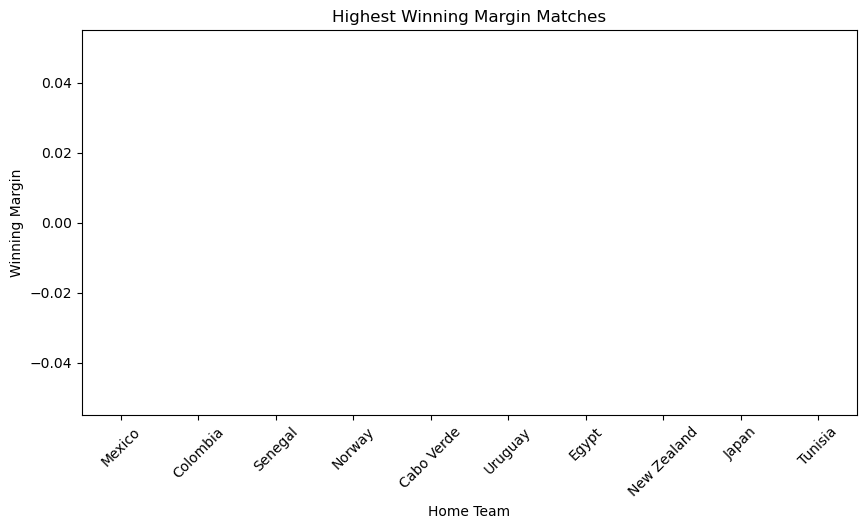

In [113]:
top_margin.head(10).plot(
    x="Home_Team",
    y="Winning_Margin",
    kind="bar",
    figsize=(10,5),
    legend=False
)

plt.title("Highest Winning Margin Matches")
plt.xlabel("Home Team")
plt.ylabel("Winning Margin")
plt.xticks(rotation=45)
plt.show()

In [114]:
print(df[["home_score", "away_score", "Winning_Margin"]].head(15))

    home_score  away_score  Winning_Margin
0          2.0         0.0             2.0
1          2.0         1.0             1.0
2          1.0         1.0             0.0
3          4.0         1.0             3.0
4          1.0         1.0             0.0
5          1.0         1.0             0.0
6          0.0         1.0             1.0
7          2.0         0.0             2.0
8          7.0         1.0             6.0
9          2.0         2.0             0.0
10         1.0         0.0             1.0
11         5.0         1.0             4.0
12         0.0         0.0             0.0
13         1.0         1.0             0.0
14         1.0         1.0             0.0


In [115]:
# Recreate Winning_Margin
df["Winning_Margin"] = abs(df["home_score"] - df["away_score"])

In [116]:
# Recreate top_margin
top_margin = df.sort_values(by="Winning_Margin", ascending=False)

# Project Summary
Summarizing key findings and insights obtained from football analytics.

In [117]:
# Check top 10
print(top_margin[["Home_Team", "Winning_Margin"]].head(10))

      Home_Team  Winning_Margin
8       Germany             6.0
26       Canada             6.0
44     Portugal             5.0
65      Senegal             5.0
35      Tunisia             4.0
34  Netherlands             4.0
60  New Zealand             4.0
11       Sweden             4.0
38        Spain             4.0
27  Switzerland             3.0


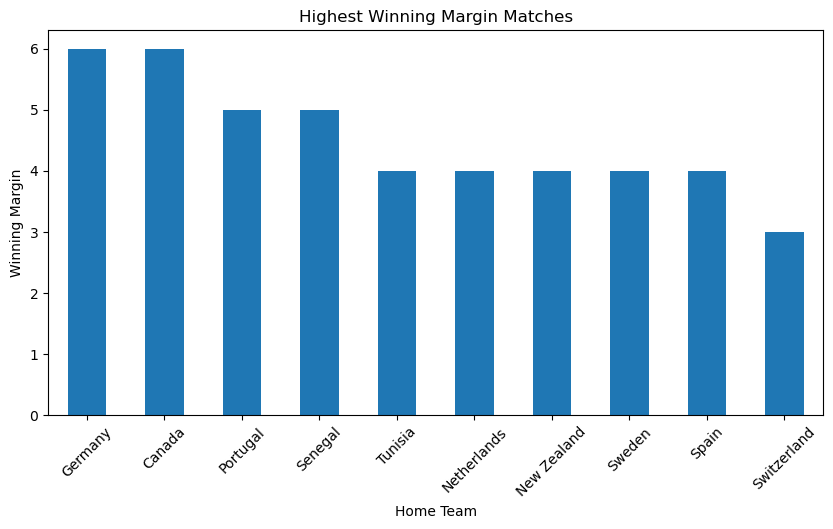

In [118]:
top_margin.head(10).plot(
    x="Home_Team",
    y="Winning_Margin",
    kind="bar",
    figsize=(10,5),
    legend=False
)

plt.title("Highest Winning Margin Matches")
plt.xlabel("Home Team")
plt.ylabel("Winning Margin")
plt.xticks(rotation=45)
plt.show()

In [119]:
print("="*50)
print("FOOTBALL ANALYTICS PROJECT SUMMARY")
print("="*50)

print(f"Total Matches : {len(df)}")
print(f"Completed Matches : {len(df[df['status']=='Completed'])}")
print(f"Scheduled Matches : {len(df[df['status']=='Scheduled'])}")

print(f"\nTotal Goals : {df['Total_Goals'].sum()}")
print(f"Average Goals Per Match : {round(df['Total_Goals'].mean(),2)}")

print(f"\nHighest Goals in a Match : {df['Total_Goals'].max()}")
print(f"Average Winning Margin : {round(df['Winning_Margin'].mean(),2)}")

print("="*50)

FOOTBALL ANALYTICS PROJECT SUMMARY
Total Matches : 89
Completed Matches : 85
Scheduled Matches : 4

Total Goals : 249
Average Goals Per Match : 2.8

Highest Goals in a Match : 8
Average Winning Margin : 1.61


In [120]:
team_goals = (
    df.groupby("Home_Team")["home_score"].sum()
    .add(df.groupby("Away_Team")["away_score"].sum(), fill_value=0)
)

team_goals.sort_values(ascending=False).head(5)

Home_Team
France         13.0
Germany        11.0
Netherlands    11.0
Norway         10.0
Senegal        10.0
dtype: float64

In [121]:
goal_efficiency = (
    df.groupby("Home_Team")["Home_Goal_Efficiency"]
    .mean()
    .sort_values(ascending=False)
)

goal_efficiency.head(5)

Home_Team
Croatia                   4.760000
Netherlands               2.276667
Bosnia and Herzegovina    2.030000
New Zealand               1.950000
Algeria                   1.850000
Name: Home_Goal_Efficiency, dtype: float64

In [122]:
df.tail()

,match_id,date,kickoff_time_utc,stage_id,venue_id,home_team_id,away_team_id,home_score,away_score,status,...,Goal_Category,Winning_Margin,High_Scoring_Match,Home_Attack_Rating,Away_Attack_Rating,Home_Defense_Rating,Away_Defense_Rating,Home_Goal_Efficiency,Away_Goal_Efficiency,Match_Intensity
84,85,03-07-2026,9:00,2,5,8,38,2.0,0.0,Completed,...,Low Scoring,2.0,No,Average,Poor,Excellent,Good,0.79,0.0,Low
85,86,04-07-2026,0:00,2,4,15,26,NaN,NaN,Scheduled,...,Low Scoring,NaN,No,Strong,Strong,Weak,Weak,NaN,NaN,Low
86,87,04-07-2026,4:00,2,13,37,30,NaN,NaN,Scheduled,...,Low Scoring,NaN,No,Strong,Strong,Weak,Weak,NaN,NaN,Low
87,88,04-07-2026,7:30,2,12,44,47,NaN,NaN,Scheduled,...,Low Scoring,NaN,No,Strong,Strong,Weak,Weak,NaN,NaN,Low
88,89,04-07-2026,23:00,3,11,5,14,NaN,NaN,Scheduled,...,Low Scoring,NaN,No,Strong,Strong,Weak,Weak,NaN,NaN,Low


In [123]:
df.to_csv("football_final_dataset.csv", index=False)

In [124]:
import os

os.listdir()

['.ipynb_checkpoints',
 'anaconda_projects',
 'Cleaned Data',
 'Football_Analytics.ipynb',
 'Football_Analytics.xlsx.xlsx',
 'football_final_dataset.csv',
 'matches_clean.csv.csv',
 'Raw Data']